# BUSN 32120 Data Analysis with Python and SQL
# Final Project
### Group 20: wang277y@uchicago.edu, makiyahm@uchicago.edu

## Introduction 

Air pollution remains a persistent public health concern in China, particularly in its major cities such as Beijing. In our analysis, we are targeting Beijing residents, commuters, and individuals who regularly spend time outdoors, including students, workers, and those with health conditions that make them more sensitive to air quality. This data could also be useful for others attempting similar projects and attempts to mimic analysis one might take if they were in they were in the fields of energy or government. For this audience, understanding when air pollution is typically at its worst is critical for making everyday decisions such as limiting outdoor activities, adjusting commuting times, or taking protective measures. In professional or academic settings, this analysis could be used to make informative decisions on policy or impact investing. 

The primary goal for this analysis is that air quality in Beijing is not constant and it varies across time due to changing environmental and atmospheric conditions. Additionally, the Chinese government has made increased efforts over the years to increase the market share of electric vehicles to aid in its goal of carbon neutrality. This project examines hourly and monthly air quality data aggregated to the daily level to identify broader temporal patterns. It also examines monthly electric vechicle sales and the relationship it may have with pm25, one of the most common air pollutants. The time period for this analysis takes place from February 1, 2024, to February 1, 2026 to capture all possible weather conditions within a year, along with including enough data points for statistical significance. 

In the first part of the analysis, we use data from the Open-Meteo Air Quality API to address the central research question: When and in what conditions is Beijing’s air quality the worst? The data set includes the measurements of the 6 most common air pollutants: PM2_5, PM 10,	Ozone (Smog), NO2, CO, and SO2. By transforming high-frequency pollution measurements into monthly summaries, this analysis aims to provide an overview of pollution trends and help highlight periods of elevated health risk. 

Aggregating into daily data is another quality we chose for part two of our analysis. We used weather data from NASA’s website. We were able to select the variables and time range that we were interested in to create our initial data frame. The variables chosen were wind, temperature, precipitation, pressure, and humidity. However, we chose not to use pressure as it was not as volatile as the other variables; therefore, we assumed it would have little impact on our questions. This portion helps answer the second part of our question by looking at what combination of conditions may result in harsher air pollutant quality.  

We later joined the weather conditions and pollutant data sets together to explore our questions further.  

As we continued investigating, we wondered what other factors may impact air quality, so we decided to add an electric vehicle data set as a reference to China's efforts. In this section, we asked, How do EV sales impact pollution? The data set was aggregated by month and joined with the pollutant data set to answer these questions 

A combination of Python and SQL was used to explore these topics.

In [1]:
import requests
import pandas as pd
import numpy as np

# Beijing coordinates
LAT, LON = 39.9042, 116.4074

def fetch_open_meteo_air_quality(lat, lon, start_date, end_date):
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": ["pm2_5", "pm10", "ozone", "nitrogen_dioxide", "carbon_monoxide", "sulphur_dioxide"],
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "Asia/Shanghai"
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    return df

aq_hourly = fetch_open_meteo_air_quality(LAT, LON, "2024-02-01", "2026-02-01")
aq_hourly.head()


,time,pm2_5,pm10,ozone,nitrogen_dioxide,carbon_monoxide,sulphur_dioxide
0,2024-02-01 00:00:00,121.1,174.2,0.0,56.8,1875.0,116.9
1,2024-02-01 01:00:00,93.4,134.6,0.0,58.4,1447.0,84.9
2,2024-02-01 02:00:00,76.6,110.4,0.0,59.5,1117.0,61.1
3,2024-02-01 03:00:00,68.9,99.2,0.0,59.6,979.0,52.5
4,2024-02-01 04:00:00,63.3,91.0,0.0,59.2,938.0,52.0


In [2]:
aq_hourly = fetch_open_meteo_air_quality(LAT, LON, "2024-02-01", "2026-02-01")
aq_hourly.head()

,time,pm2_5,pm10,ozone,nitrogen_dioxide,carbon_monoxide,sulphur_dioxide
0,2024-02-01 00:00:00,121.1,174.2,0.0,56.8,1875.0,116.9
1,2024-02-01 01:00:00,93.4,134.6,0.0,58.4,1447.0,84.9
2,2024-02-01 02:00:00,76.6,110.4,0.0,59.5,1117.0,61.1
3,2024-02-01 03:00:00,68.9,99.2,0.0,59.6,979.0,52.5
4,2024-02-01 04:00:00,63.3,91.0,0.0,59.2,938.0,52.0


In [3]:
# creating date time variable and date column 
aq_hourly["time"] = pd.to_datetime(aq_hourly["time"])

In [4]:
aq_hourly["year"] = aq_hourly["time"].dt.year
aq_hourly["month"] = aq_hourly["time"].dt.month
aq_hourly["day"] = aq_hourly["time"].dt.day
aq_hourly["date"] = aq_hourly["time"].dt.date

In [5]:
pollutants = [
    "pm2_5", "pm10", "ozone",
    "nitrogen_dioxide", "carbon_monoxide", "sulphur_dioxide"
]

aq_hourly = aq_hourly.dropna(subset=pollutants)

In [6]:
# for loop that matches the columns/data by a date groupby 
daily_rows = []

for date, group in aq_hourly.groupby("date"):
    daily_dict = {
        "date": pd.to_datetime(date),
        "year": int(group["year"].iloc[0]),
        "month": int(group["month"].iloc[0]),
        "pm2_5_mean": group["pm2_5"].mean(),
        "pm2_5_max": group["pm2_5"].max(),
        "pm10_mean": group["pm10"].mean(),
        "ozone_mean": group["ozone"].mean(),
        "no2_mean": group["nitrogen_dioxide"].mean(),
        "co_mean": group["carbon_monoxide"].mean(),
        "so2_mean": group["sulphur_dioxide"].mean(),
        "hours_observed": len(group)
    }
    daily_rows.append(daily_dict)

In [7]:
aq_daily = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)

In [8]:
aq_daily["date"] = pd.to_datetime(aq_daily["date"])
aq_daily.head()

,date,year,month,pm2_5_mean,pm2_5_max,pm10_mean,ozone_mean,no2_mean,co_mean,so2_mean,hours_observed
0,2024-02-01,2024,2,87.204167,206.3,125.283333,8.916667,53.562500,1213.708333,83.200000,24
1,2024-02-02,2024,2,163.695833,378.1,235.437500,3.458333,51.420833,2149.958333,156.991667,24
2,2024-02-03,2024,2,249.675000,435.9,358.533333,4.166667,59.566667,3276.291667,243.591667,24
3,2024-02-04,2024,2,196.404167,336.2,281.816667,2.500000,58.537500,2741.000000,186.404167,24
4,2024-02-05,2024,2,162.458333,285.0,234.387500,10.208333,65.420833,2117.125000,137.958333,24


#### Aq_daily EDA 

In [9]:
aq_daily.shape

(732, 11)

In [10]:
aq_daily.columns

Index(['date', 'year', 'month', 'pm2_5_mean', 'pm2_5_max', 'pm10_mean',
       'ozone_mean', 'no2_mean', 'co_mean', 'so2_mean', 'hours_observed'],
      dtype='str')

In [11]:
aq_daily.dtypes

date              datetime64[s]
year                      int64
month                     int64
pm2_5_mean              float64
pm2_5_max               float64
pm10_mean               float64
ozone_mean              float64
no2_mean                float64
co_mean                 float64
so2_mean                float64
hours_observed            int64
dtype: object

In [12]:
aq_daily.describe()

,date,year,month,pm2_5_mean,pm2_5_max,pm10_mean,ozone_mean,no2_mean,co_mean,so2_mean,hours_observed
count,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.0
mean,2025-01-31 12:00:00,2024.586066,6.513661,82.393505,154.228552,103.492321,39.183572,55.660997,1324.438866,60.040289,24.0
min,2024-02-01 00:00:00,2024.000000,1.000000,10.275000,19.600000,12.641667,0.333333,6.129167,235.916667,4.816667,24.0
25%,2024-08-01 18:00:00,2024.000000,4.000000,48.512500,91.450000,65.176042,13.791667,44.558333,609.072917,32.876042,24.0
50%,2025-01-31 12:00:00,2025.000000,7.000000,71.420833,134.350000,93.293750,34.062500,53.535417,942.645833,46.372917,24.0
75%,2025-08-02 06:00:00,2025.000000,10.000000,102.883333,197.400000,131.323958,60.062500,64.694792,1665.083333,74.067708,24.0
max,2026-02-01 00:00:00,2026.000000,12.000000,275.004167,446.100000,358.533333,126.916667,122.875000,5948.708333,243.591667,24.0
std,NaN,0.574870,3.453594,47.084795,84.052105,54.077997,29.639953,17.777171,1047.502143,42.289141,0.0


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

In [14]:
print("pandas version ", pd.__version__)
print("sklearn version ", sklearn.__version__)
print("seaborn version ", sns.__version__)

pandas version  3.0.0rc0
sklearn version  1.8.0
seaborn version  0.13.2


In [15]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

We create a histogram of hourly PM2.5 concentrations to understand the overall distribution of air pollution levels in Beijing. 
This visualization allows us to examine how pollution is spread across different concentration levels and how frequently extreme pollution events occur.

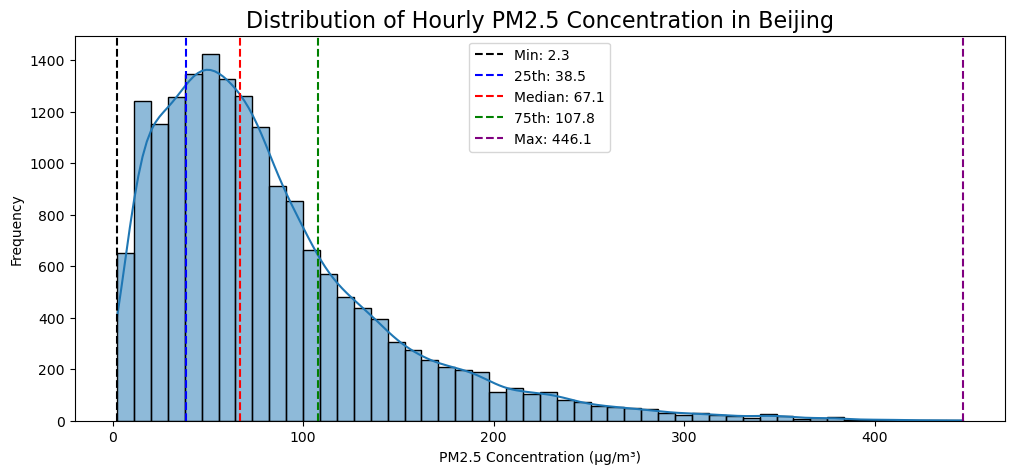

In [17]:
#creating the chart 

pm25 = aq_hourly["pm2_5"]

p25 = pm25.quantile(0.25)
p50 = pm25.quantile(0.50)
p75 = pm25.quantile(0.75)
min_val = pm25.min()
max_val = pm25.max()

plt.figure(figsize=(12, 5))
sns.histplot(pm25, bins=50, kde=True)

# Add vertical lines
plt.axvline(min_val, color="black", linestyle="--", label=f"Min: {min_val:.1f}")
plt.axvline(p25, color="blue", linestyle="--", label=f"25th: {p25:.1f}")
plt.axvline(p50, color="red", linestyle="--", label=f"Median: {p50:.1f}")
plt.axvline(p75, color="green", linestyle="--", label=f"75th: {p75:.1f}")
plt.axvline(max_val, color="purple", linestyle="--", label=f"Max: {max_val:.1f}")

plt.title("Distribution of Hourly PM2.5 Concentration in Beijing", fontsize=16)
plt.xlabel("PM2.5 Concentration (µg/m³)")
plt.ylabel("Frequency")

plt.legend()
plt.show()

This histogram suggests that while average pollution may appear moderate, residents still experience occasional high-exposure hours that could pose significant health risks for Beijing residents.

#### How does PM2.5 concentration change over time in Beijing?
We will create a plot to explore the overall time trend in Beijing's air pollution. Additionally, By aggregating hourly PM2.5 data into daily averages. we reduce short-term fluctuations and highlight broader patterns. This allows us to see whether pollution levels are increasing, decreasing, or showing seasonal cycles over time.

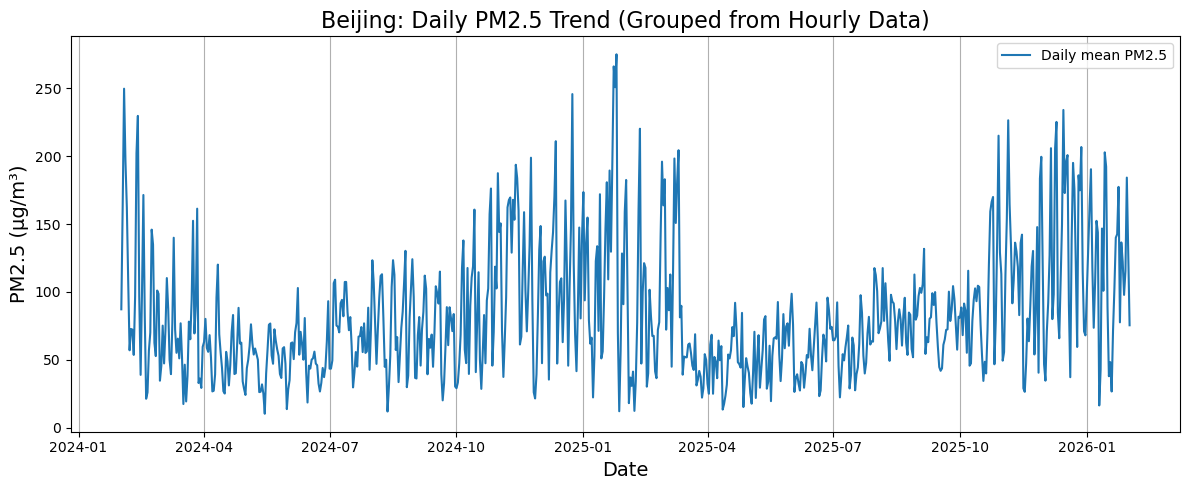

In [18]:
aq_hourly["time"] = pd.to_datetime(aq_hourly["time"])

# Create a daily date key (midnight timestamp)
aq_hourly["date"] = aq_hourly["time"].dt.floor("D")

# Groupby to compute daily average PM2.5
daily_pm25 = (
    aq_hourly.groupby("date")["pm2_5"]
    .mean()
    .dropna()
)

# Plot daily trend
plt.figure(figsize=(12, 5))
plt.plot(daily_pm25.index, daily_pm25.values, label="Daily mean PM2.5")

plt.xlabel("Date", fontsize=14)
plt.ylabel("PM2.5 (µg/m³)", fontsize=14)
plt.title("Beijing: Daily PM2.5 Trend (Grouped from Hourly Data)", fontsize=16)
plt.grid(axis="x")
plt.legend()
plt.tight_layout()
plt.show()

The daily PM2.5 level fluctuates over the year and it shows a seasonal trend.

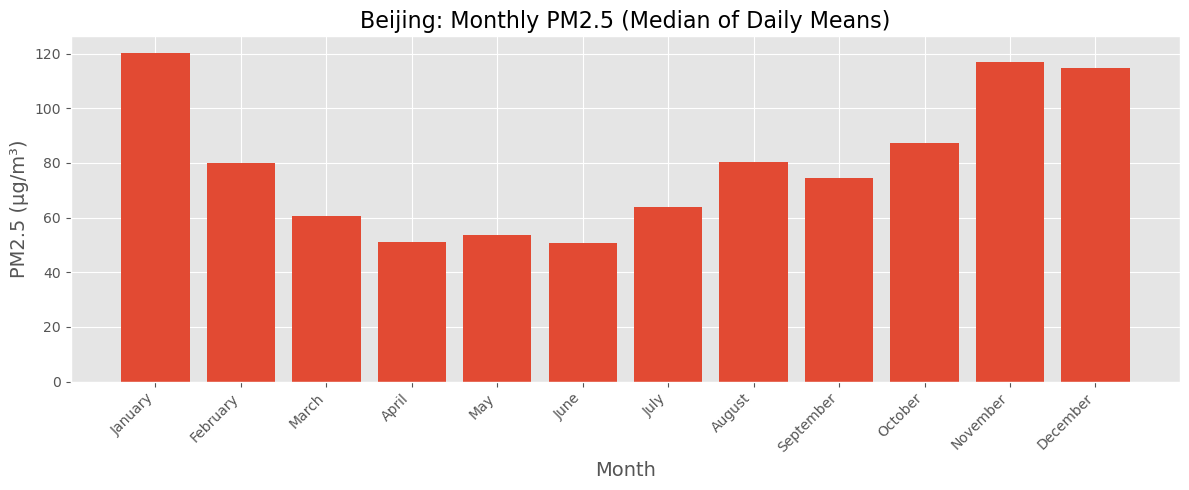

In [19]:
# We create this bar chart to examine the monthly pattern of PM2.5 concentrations in Beijing
aq_daily["month_num"] = aq_daily["date"].dt.month

# Monthly median of daily mean PM2.5
monthly_average = (
    aq_daily.groupby("month_num")["pm2_5_mean"]
    .median()
    .reindex(range(1, 13))
)

# Convert month numbers to names
month_names = pd.date_range("2024-01-01", periods=12, freq="MS").strftime("%B")
monthly_average.index = month_names

monthly_average = monthly_average.round(1)

# Plot
with plt.style.context("ggplot"):
    plt.figure(figsize=(12, 5))
    plt.bar(monthly_average.index, monthly_average.values)
    plt.xlabel("Month", fontsize=14)
    plt.ylabel("PM2.5 (µg/m³)", fontsize=14)
    plt.title("Beijing: Monthly PM2.5 (Median of Daily Means)", fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

These two plots show that air pollution in Beijing is usually higher in winter between November to Janurary.

#### Weather Conditions Data Set 

In [20]:
#Second Data Set 

import requests 
import json
import numpy as np
from pprint import pprint 
import seaborn as sns
import pandas as pd
import os

In [21]:
print(os.path.join(os.getcwd(), 'POWER_Point_Daily_20240201_20260201_.csv'))

/home/makiyahm/Midterm/POWER_Point_Daily_20240201_20260201_.csv


In [22]:
Beijing_Weather_df= pd.read_csv('/home/makiyahm/Midterm/POWER_Point_Daily_20240201_20260201_.csv')

In [23]:
Beijing_Weather_df.head(10)

,YEAR,DOY,T2M,RH2M,PRECTOTCORR,WS2M,PS
0,2024,32,-7.51,49.30,0.00,0.97,100.97
1,2024,33,-6.63,59.39,0.00,1.02,100.62
2,2024,34,-3.66,55.85,0.00,1.07,100.72
3,2024,35,-4.91,64.77,0.24,1.10,100.49
4,2024,36,-2.74,65.55,0.42,1.15,100.22
5,2024,37,-2.25,56.42,0.03,2.06,100.37
6,2024,38,-2.86,46.26,0.00,2.64,100.25
7,2024,39,-2.62,49.24,0.00,2.22,99.76
8,2024,40,-1.43,48.63,0.00,3.40,99.48
9,2024,41,-2.12,46.34,0.00,2.76,99.87


In [24]:
#searching for nulls
Beijing_Weather_df.isnull().sum()

YEAR           0
DOY            0
T2M            0
RH2M           0
PRECTOTCORR    0
WS2M           0
PS             0
dtype: int64

In [25]:
(Beijing_Weather_df == -999).sum()

YEAR           0
DOY            0
T2M            2
RH2M           2
PRECTOTCORR    2
WS2M           2
PS             2
dtype: int64

In [26]:
Beijing_Weather_df.shape

(732, 7)

In [27]:
Beijing_Weather_df.replace(-999, np.nan, inplace=True)
Beijing_Weather_df.dropna(inplace=True)


We dropped these nulls since there was only two of them. We do not think it will impact our analysis significantly 

In [28]:
(Beijing_Weather_df == -999).sum()

YEAR           0
DOY            0
T2M            0
RH2M           0
PRECTOTCORR    0
WS2M           0
PS             0
dtype: int64

In [29]:
Beijing_Weather_df.shape

(730, 7)

In [30]:
#creating date column and variable 
Beijing_Weather_df["Date"] = (
    pd.to_datetime(Beijing_Weather_df["YEAR"].astype(str) + "-01-01")
    + pd.to_timedelta(Beijing_Weather_df["DOY"] - 1, unit="D")
)


#### Weather Conditions EDA 

In [31]:
Beijing_Weather_df.head()

,YEAR,DOY,T2M,RH2M,PRECTOTCORR,WS2M,PS,Date
0,2024,32,-7.51,49.30,0.00,0.97,100.97,2024-02-01
1,2024,33,-6.63,59.39,0.00,1.02,100.62,2024-02-02
2,2024,34,-3.66,55.85,0.00,1.07,100.72,2024-02-03
3,2024,35,-4.91,64.77,0.24,1.10,100.49,2024-02-04
4,2024,36,-2.74,65.55,0.42,1.15,100.22,2024-02-05


In [32]:
Beijing_Weather_df.sample()

,YEAR,DOY,T2M,RH2M,PRECTOTCORR,WS2M,PS,Date
229,2024,261,21.77,84.0,0.16,1.49,99.1,2024-09-17


In [33]:
Beijing_Weather_df2 = Beijing_Weather_df.drop('YEAR', axis=1)

In [34]:
Beijing_Weather_df2.head()

,DOY,T2M,RH2M,PRECTOTCORR,WS2M,PS,Date
0,32,-7.51,49.30,0.00,0.97,100.97,2024-02-01
1,33,-6.63,59.39,0.00,1.02,100.62,2024-02-02
2,34,-3.66,55.85,0.00,1.07,100.72,2024-02-03
3,35,-4.91,64.77,0.24,1.10,100.49,2024-02-04
4,36,-2.74,65.55,0.42,1.15,100.22,2024-02-05


In [35]:
Beijing_Weather_df2.rename(columns = {'T2M':'Temperature', 'RH2M': 'Humidity','PRECTOTCORR':'Precepitation','WS2M':'Wind','PS':'Pressure'}, inplace = True)
Beijing_Weather_df2.sample()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date
705,6,-2.71,54.17,0.0,2.36,99.14,2026-01-06


In [36]:
Beijing_Weather_df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DOY            730 non-null    int64         
 1   Temperature    730 non-null    float64       
 2   Humidity       730 non-null    float64       
 3   Precepitation  730 non-null    float64       
 4   Wind           730 non-null    float64       
 5   Pressure       730 non-null    float64       
 6   Date           730 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 40.1 KB


In [37]:
Beijing_Weather_df2.describe()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730
mean,183.458904,12.304795,60.661712,2.544671,2.196178,98.943959,2025-01-30 12:00:00
min,1.000000,-11.830000,17.390000,0.000000,0.540000,96.800000,2024-02-01 00:00:00
25%,92.250000,0.945000,47.682500,0.000000,1.452500,98.202500,2024-08-01 06:00:00
50%,183.500000,13.425000,60.795000,0.010000,1.975000,98.950000,2025-01-30 12:00:00
75%,274.750000,23.445000,74.207500,0.917500,2.635000,99.665000,2025-07-31 18:00:00
max,366.000000,31.160000,95.360000,95.620000,9.710000,101.100000,2026-01-30 00:00:00
std,105.504804,11.643591,16.892313,8.559664,1.062264,0.947013,NaN


In [38]:
Beijing_Weather_df3=Beijing_Weather_df2.copy()
Beijing_Weather_df3["Year"] = Beijing_Weather_df3["Date"].dt.year
Beijing_Weather_df3["Month"] = Beijing_Weather_df3["Date"].dt.month
Beijing_Weather_df3["Day"] = Beijing_Weather_df3["Date"].dt.day

In [39]:
Beijing_Weather_df3.head()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date,Year,Month,Day
0,32,-7.51,49.30,0.00,0.97,100.97,2024-02-01,2024,2,1
1,33,-6.63,59.39,0.00,1.02,100.62,2024-02-02,2024,2,2
2,34,-3.66,55.85,0.00,1.07,100.72,2024-02-03,2024,2,3
3,35,-4.91,64.77,0.24,1.10,100.49,2024-02-04,2024,2,4
4,36,-2.74,65.55,0.42,1.15,100.22,2024-02-05,2024,2,5


In [40]:
Beijing_Weather_df4 = Beijing_Weather_df3[['Date','Temperature', 'Humidity', 'Precepitation']]
Beijing_Weather_df4.head(1)

,Date,Temperature,Humidity,Precepitation
0,2024-02-01,-7.51,49.3,0.0


<Axes: >

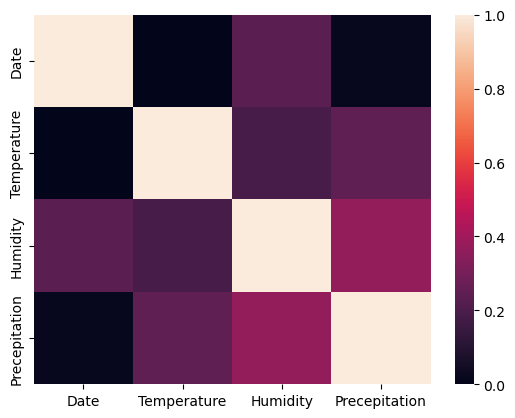

In [41]:
sns.heatmap(Beijing_Weather_df4.corr(), vmin=0, vmax=1)

In [42]:
import matplotlib.pyplot as plt

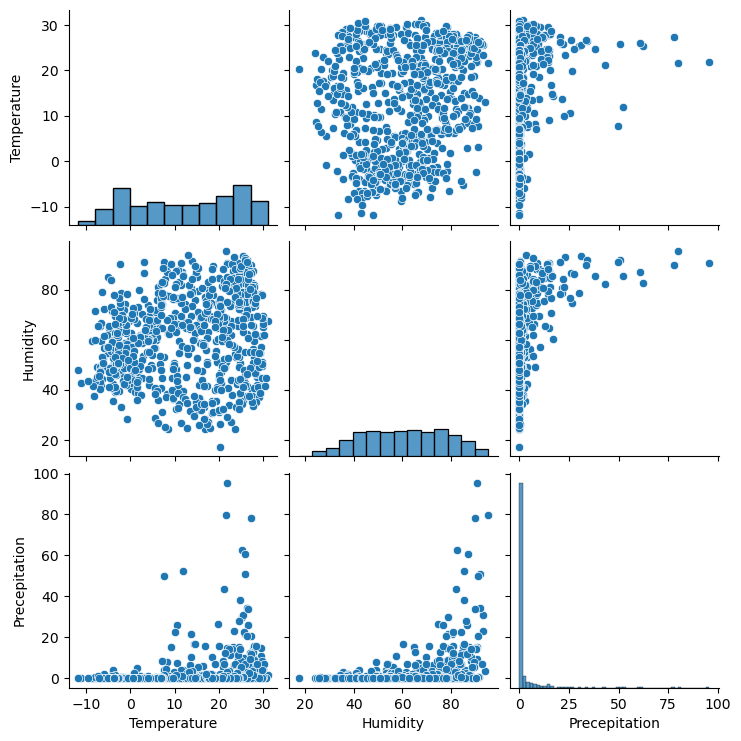

In [43]:
#creating a pairplot for further comparison
sns.pairplot(Beijing_Weather_df4)

We thought a pairplot would help reveal another pattern since the variables seem uncorrelated with eachother, however, it seems to have confirmed this realization further. 

In [44]:
#creating season as a column and variable 
conditions = [
    Beijing_Weather_df3["Month"].isin([12, 1, 2]),
   Beijing_Weather_df3["Month"].isin([3, 4, 5]),
    Beijing_Weather_df3["Month"].isin([6, 7, 8]),
    Beijing_Weather_df3["Month"].isin([9, 10, 11])
]

choices = ["Winter", "Spring", "Summer", "Fall"]

Beijing_Weather_df3["Season"] = np.select(conditions, choices, default="Unknown")
Beijing_Weather_df3.head()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date,Year,Month,Day,Season
0,32,-7.51,49.30,0.00,0.97,100.97,2024-02-01,2024,2,1,Winter
1,33,-6.63,59.39,0.00,1.02,100.62,2024-02-02,2024,2,2,Winter
2,34,-3.66,55.85,0.00,1.07,100.72,2024-02-03,2024,2,3,Winter
3,35,-4.91,64.77,0.24,1.10,100.49,2024-02-04,2024,2,4,Winter
4,36,-2.74,65.55,0.42,1.15,100.22,2024-02-05,2024,2,5,Winter


In [45]:
#using map as a way to create season into dummy variables 
Beijing_Weather_df3_2 = Beijing_Weather_df3.copy()
Beijing_Weather_df3_2["Season_Winter"] = Beijing_Weather_df3_2["Season"].map(lambda x: 1 if x == "Winter" else 0)
Beijing_Weather_df3_2["Season_Spring"] = Beijing_Weather_df3_2["Season"].map(lambda x: 1 if x == "Spring" else 0)
Beijing_Weather_df3_2["Season_Summer"] = Beijing_Weather_df3_2["Season"].map(lambda x: 1 if x == "Summer" else 0)
Beijing_Weather_df3_2["Season_Fall"]   = Beijing_Weather_df3_2["Season"].map(lambda x: 1 if x == "Fall" else 0)

Beijing_Weather_df3_2.sample()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date,Year,Month,Day,Season,Season_Winter,Season_Spring,Season_Summer,Season_Fall
433,99,13.73,56.5,0.76,1.26,98.28,2025-04-09,2025,4,9,Spring,0,1,0,0


In [46]:
#However, I prefer turning season into a dummy variable to be used in regression analysis using this method because it's cleaner 
Beijing_Weather_df4 = pd.get_dummies(Beijing_Weather_df3, columns=["Season"], drop_first=True)

In [47]:
#creating the median for precipitation and temperature for distribution charts
Precepitation_monthly_median = Beijing_Weather_df4.groupby("Month")["Precepitation"].median()
Temperature_monthly_median = Beijing_Weather_df4.groupby("Month")["Temperature"].median()

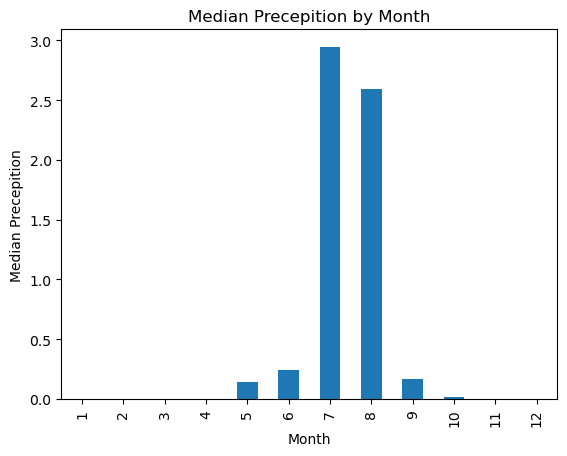

In [48]:
plt.figure()
Precepitation_monthly_median.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Median Precepition")
plt.title("Median Precepition by Month")

plt.show()

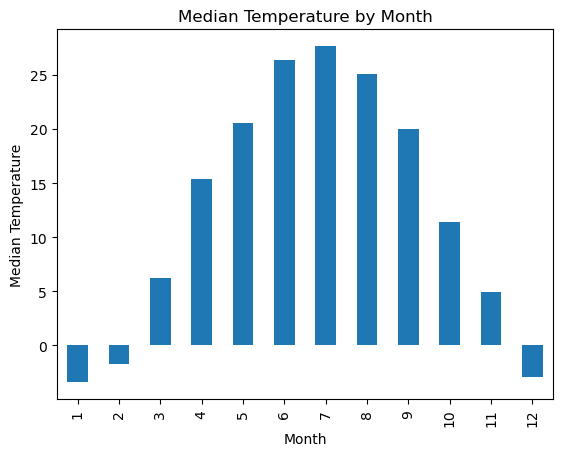

In [49]:
plt.figure()
Temperature_monthly_median.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Median Temperature")
plt.title("Median Temperature by Month")

plt.show()

In [50]:
#the start for merging the data frames together  
Beijing_Weather_df4.index

RangeIndex(start=0, stop=730, step=1)

In [51]:
Beijing_Weather_df4.columns 

Index(['DOY', 'Temperature', 'Humidity', 'Precepitation', 'Wind', 'Pressure',
       'Date', 'Year', 'Month', 'Day', 'Season_Spring', 'Season_Summer',
       'Season_Winter'],
      dtype='str')

In [52]:
aq_daily.columns 

Index(['date', 'year', 'month', 'pm2_5_mean', 'pm2_5_max', 'pm10_mean',
       'ozone_mean', 'no2_mean', 'co_mean', 'so2_mean', 'hours_observed',
       'month_num'],
      dtype='str')

In [53]:
merged_df = Beijing_Weather_df4.merge(aq_daily,left_on="Date", right_on="date")

In [54]:
merged_df.head()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date,Year,Month,Day,...,month,pm2_5_mean,pm2_5_max,pm10_mean,ozone_mean,no2_mean,co_mean,so2_mean,hours_observed,month_num
0,32,-7.51,49.30,0.00,0.97,100.97,2024-02-01,2024,2,1,...,2,87.204167,206.3,125.283333,8.916667,53.562500,1213.708333,83.200000,24,2
1,33,-6.63,59.39,0.00,1.02,100.62,2024-02-02,2024,2,2,...,2,163.695833,378.1,235.437500,3.458333,51.420833,2149.958333,156.991667,24,2
2,34,-3.66,55.85,0.00,1.07,100.72,2024-02-03,2024,2,3,...,2,249.675000,435.9,358.533333,4.166667,59.566667,3276.291667,243.591667,24,2
3,35,-4.91,64.77,0.24,1.10,100.49,2024-02-04,2024,2,4,...,2,196.404167,336.2,281.816667,2.500000,58.537500,2741.000000,186.404167,24,2
4,36,-2.74,65.55,0.42,1.15,100.22,2024-02-05,2024,2,5,...,2,162.458333,285.0,234.387500,10.208333,65.420833,2117.125000,137.958333,24,2


In [55]:
# drop duplicate columns 
merged_df2 = merged_df.drop(columns=['date','year','month'])

merged_df2.head()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date,Year,Month,Day,...,Season_Winter,pm2_5_mean,pm2_5_max,pm10_mean,ozone_mean,no2_mean,co_mean,so2_mean,hours_observed,month_num
0,32,-7.51,49.30,0.00,0.97,100.97,2024-02-01,2024,2,1,...,True,87.204167,206.3,125.283333,8.916667,53.562500,1213.708333,83.200000,24,2
1,33,-6.63,59.39,0.00,1.02,100.62,2024-02-02,2024,2,2,...,True,163.695833,378.1,235.437500,3.458333,51.420833,2149.958333,156.991667,24,2
2,34,-3.66,55.85,0.00,1.07,100.72,2024-02-03,2024,2,3,...,True,249.675000,435.9,358.533333,4.166667,59.566667,3276.291667,243.591667,24,2
3,35,-4.91,64.77,0.24,1.10,100.49,2024-02-04,2024,2,4,...,True,196.404167,336.2,281.816667,2.500000,58.537500,2741.000000,186.404167,24,2
4,36,-2.74,65.55,0.42,1.15,100.22,2024-02-05,2024,2,5,...,True,162.458333,285.0,234.387500,10.208333,65.420833,2117.125000,137.958333,24,2


In [56]:
merged_df2.describe()

,DOY,Temperature,Humidity,Precepitation,Wind,Pressure,Date,Year,Month,Day,pm2_5_mean,pm2_5_max,pm10_mean,ozone_mean,no2_mean,co_mean,so2_mean,hours_observed,month_num
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.0,730.000000
mean,183.458904,12.304795,60.661712,2.544671,2.196178,98.943959,2025-01-30 12:00:00,2024.582192,6.527397,15.717808,82.341027,154.006849,103.484658,39.239726,55.674777,1323.639669,60.012957,24.0,6.527397
min,1.000000,-11.830000,17.390000,0.000000,0.540000,96.800000,2024-02-01 00:00:00,2024.000000,1.000000,1.000000,10.275000,19.600000,12.641667,0.333333,6.129167,235.916667,4.816667,24.0,1.000000
25%,92.250000,0.945000,47.682500,0.000000,1.452500,98.202500,2024-08-01 06:00:00,2024.000000,4.000000,8.000000,48.445833,91.350000,65.094792,13.708333,44.533333,608.885417,32.819792,24.0,4.000000
50%,183.500000,13.425000,60.795000,0.010000,1.975000,98.950000,2025-01-30 12:00:00,2025.000000,7.000000,16.000000,71.220833,134.100000,93.293750,34.208333,53.535417,936.562500,46.156250,24.0,7.000000
75%,274.750000,23.445000,74.207500,0.917500,2.635000,99.665000,2025-07-31 18:00:00,2025.000000,10.000000,23.000000,102.829167,197.400000,131.007292,60.187500,64.809375,1660.135417,73.913542,24.0,10.000000
max,366.000000,31.160000,95.360000,95.620000,9.710000,101.100000,2026-01-30 00:00:00,2026.000000,12.000000,31.000000,275.004167,446.100000,358.533333,126.916667,122.875000,5948.708333,243.591667,24.0,12.000000
std,105.504804,11.643591,16.892313,8.559664,1.062264,0.947013,NaN,0.570861,3.448216,8.797826,47.118804,83.977358,54.135954,29.660232,17.798425,1048.810879,42.333317,0.0,3.448216


#### Regressions from Merged Data Frames 

In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
#start of pm2_5 linear regression, defining x and y 

y = merged_df2["pm2_5_mean"]
X = merged_df2[[
    "Temperature",
    "Humidity",
    "Wind", "Precepitation", "Season_Spring",
    "Season_Summer",
    "Season_Winter"
]]

#create empty regression and run it 
merged_df2_reg = LinearRegression()
merged_df2_reg.fit(X, y)

#print results 
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": merged_df2_reg.coef_
})

print(coefficients)

print("Intercept:", merged_df2_reg.intercept_)

        Variable  Coefficient
0    Temperature    -1.048689
1       Humidity     1.226852
2           Wind   -16.003865
3  Precepitation    -0.824362
4  Season_Spring    14.592692
5  Season_Summer     0.430975
6  Season_Winter    33.071520
Intercept: 46.12563131817049


In [59]:
import statsmodels.api as sm

In [60]:
#adding results along with the statistical output to see how well the data is described by the model 

#defining terms 
y = merged_df2["pm2_5_mean"]
X = merged_df2[[
    "Temperature",
    "Humidity",
    "Wind", "Precepitation","Season_Spring",
    "Season_Summer",
    "Season_Winter"
]]

#making sure the dummy variable is numeric 

X = X.astype(float)

#Forcing an intercept 
X['intercept']= 1

# define and run regression 
merged_df2_reg = sm.OLS(y, X)

#summary table 
results = merged_df2_reg.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             pm2_5_mean   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     114.3
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          1.82e-112
Time:                        10:36:26   Log-Likelihood:                -3575.6
No. Observations:                 730   AIC:                             7167.
Df Residuals:                     722   BIC:                             7204.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Temperature      -1.0487      0.234     -4.489      0.000      -1.507      -0.590
Humidity          1.2269      0.111     11.047      0.000       1.009       1.445
Wind            -16.0039      1.443    -11.090      0.000     -18.837     -13.171
Precepitation    -0.8244      0.166     -4.977      0.000      -1.150      -0.499
Season_Spring    14.5927      4.254      3.431      0.001       6.242      22.944
Season_Summer     0.4310      4.964      0.087      0.931      -9.314      10.176
Season_Winter    33.0715      5.072      6.520      0.000      23.114      43.030
intercept        46.1256     10.515      4.387      0.000      25.482      66.769
==============================================================================
Omnibus:                       46.873   Durbin-Watson:                   1.073
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.459
Skew:                           0.553   Prob(JB):                     4.51e-14
Kurtosis:                       3.894   Cond. No.                         599.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

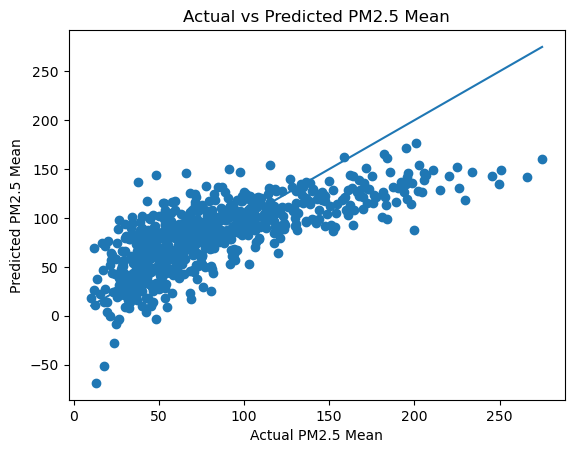

In [61]:
#defining y-pred 

y_pred = results.predict(X)

#plotting the regression 
plt.figure()

plt.scatter(y, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()]
)

plt.xlabel("Actual PM2.5 Mean")
plt.ylabel("Predicted PM2.5 Mean")
plt.title("Actual vs Predicted PM2.5 Mean")

plt.show()

In [62]:
#running a model with the columns from the heatmap/EDA plus dummy variables 

#defining terms 
y = merged_df2["pm2_5_mean"]
X = merged_df2[[
    "Temperature",
    "Humidity", "Precepitation","Season_Spring",
    "Season_Summer",
    "Season_Winter"
]]

#making sure the dummy variable is numeric 

X = X.astype(float)

#Forcing an intercept 
X['intercept']= 1

# define and run regression 
merged_df2_reg = sm.OLS(y, X)

#summary table 
results = merged_df2_reg.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             pm2_5_mean   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     96.55
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           5.34e-89
Time:                        10:36:26   Log-Likelihood:                -3633.0
No. Observations:                 730   AIC:                             7280.
Df Residuals:                     723   BIC:                             7312.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Temperature      -0.5576      0.248     -2.249      0.025      -1.044      -0.071
Humidity          1.8437      0.104     17.742      0.000       1.640       2.048
Precepitation    -1.2614      0.174     -7.253      0.000      -1.603      -0.920
Season_Spring    15.2385      4.598      3.314      0.001       6.211      24.266
Season_Summer     0.4690      5.366      0.087      0.930     -10.066      11.004
Season_Winter    41.5028      5.421      7.655      0.000      30.859      52.146
intercept       -33.6254      8.293     -4.055      0.000     -49.906     -17.345
==============================================================================
Omnibus:                       53.415   Durbin-Watson:                   1.064
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.267
Skew:                           0.603   Prob(JB):                     3.35e-16
Kurtosis:                       3.944   Cond. No.                         478.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [63]:
#defining terms 
y = merged_df2["ozone_mean"]
X = merged_df2[[
    "Temperature",
    "Humidity",
    "Wind", "Precepitation","Season_Spring",
    "Season_Summer",
    "Season_Winter"
]]

#making sure the dummy variable is numeric 

X = X.astype(float)

#Forcing an intercept 
X['intercept']= 1

# define and run regression 
merged_df2_reg = sm.OLS(y, X)

#summary table 
results = merged_df2_reg.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             ozone_mean   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     272.0
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          1.28e-197
Time:                        10:36:26   Log-Likelihood:                -3038.6
No. Observations:                 730   AIC:                             6093.
Df Residuals:                     722   BIC:                             6130.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Temperature       1.4410      0.112     12.871      0.000       1.221       1.661
Humidity         -0.2620      0.053     -4.923      0.000      -0.367      -0.158
Wind              7.0665      0.692     10.217      0.000       5.709       8.424
Precepitation    -0.2532      0.079     -3.189      0.001      -0.409      -0.097
Season_Spring    16.9009      2.039      8.291      0.000      12.899      20.903
Season_Summer    33.8475      2.379     14.229      0.000      29.177      38.518
Season_Winter    15.1459      2.431      6.231      0.000      10.374      19.918
intercept         6.0013      5.039      1.191      0.234      -3.892      15.895
==============================================================================
Omnibus:                       49.998   Durbin-Watson:                   1.095
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               68.126
Skew:                           0.564   Prob(JB):                     1.61e-15
Kurtosis:                       3.984   Cond. No.                         599.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

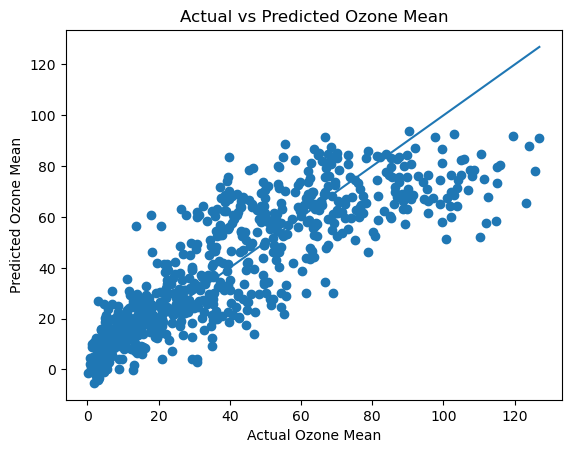

In [64]:
#defining y-pred 

y_pred = results.predict(X)

#plotting the regression 
plt.figure()

plt.scatter(y, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()]
)

plt.xlabel("Actual Ozone Mean")
plt.ylabel("Predicted Ozone Mean")
plt.title("Actual vs Predicted Ozone Mean")

plt.show()

In [65]:
#defining terms 
y = merged_df2["pm10_mean"]
X = merged_df2[[
    "Temperature",
    "Humidity",
    "Wind", "Precepitation","Season_Spring",
    "Season_Summer",
    "Season_Winter"
]]

#making sure the dummy variable is numeric 

X = X.astype(float)

#Forcing an intercept 
X['intercept']= 1

# define and run regression 
merged_df2_reg = sm.OLS(y, X)

#summary table 
results = merged_df2_reg.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              pm10_mean   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.347
Method:                 Least Squares   F-statistic:                     56.40
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.34e-64
Time:                        10:36:27   Log-Likelihood:                -3789.9
No. Observations:                 730   AIC:                             7596.
Df Residuals:                     722   BIC:                             7633.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Temperature      -0.9374      0.313     -2.992      0.003      -1.553      -0.322
Humidity          1.1274      0.149      7.568      0.000       0.835       1.420
Wind            -17.9674      1.936     -9.282      0.000     -21.768     -14.167
Precepitation    -0.9394      0.222     -4.229      0.000      -1.376      -0.503
Season_Spring    20.9829      5.705      3.678      0.000       9.782      32.184
Season_Summer    -4.6813      6.658     -0.703      0.482     -17.752       8.389
Season_Winter    24.1545      6.803      3.550      0.000      10.798      37.511
intercept        78.4169     14.103      5.560      0.000      50.729     106.105
==============================================================================
Omnibus:                      168.045   Durbin-Watson:                   1.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              453.451
Skew:                           1.156   Prob(JB):                     3.42e-99
Kurtosis:                       6.093   Cond. No.                         599.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

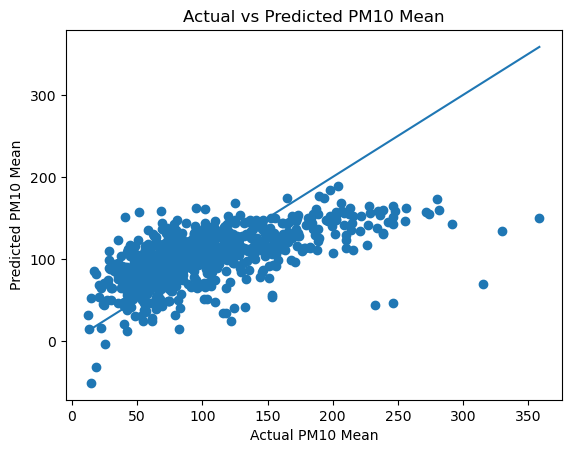

In [66]:
#defining y-pred 

y_pred = results.predict(X)

#plotting the regression 
plt.figure()

plt.scatter(y, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()]
)

plt.xlabel("Actual PM10 Mean")
plt.ylabel("Predicted PM10 Mean")
plt.title("Actual vs Predicted PM10 Mean")

plt.show()

## Conclusion 

This dataset shows the air quality and temporal patterns within Beijing, with pollution levels varying systematically across time rather than occurring at random. By aggregating hourly measurements into daily averages and maximum values, the results highlight periods in the year when air quality tends to be worse. From the EDA, we can tell that Beijing’s air quality tends to be at a moderate air pollution level. This report will offer insights for residents and commuters who wish to reduce exposure during high-risk times. Additionally, this report will highlight daily PM2.5 levels, which serve as a key indicator of poor air quality because of their strong association with adverse health outcomes and overall pollution severity.

Incorporating daily weather data, such as wind speed, humidity, and temperature, allows for a deeper exploration of how meteorological conditions influence pollution levels. The initial EDA gives insight into what the average weather day may look like in Beijing. It also suggests that the most volatile of the weather conditions are humidity and precipitation. Upon further exploration, the linear regressions also appear to suggest that weather conditions may not predict PM25 outputs, at least on the monthly average level. We went in to add a heat map about these variables after having this realization. However, the correlations between them appear to be weak. This implies that there are other factors or underlying conditions that should be considered in this analysis. This is backed up when we began running regression on pm25. One model was ran with just the variables from the heat map, and it was only when more factors were added that the r squared increased to a stronger number. We also see a weak correlation trend when running a regression on ozone pollutants, which again suggests there may be better variables to run such a regression on. In conjunction with other measurements, such as the median, we hoped to reveal other or stronger trends amongst these variables. 

Through our EDA, regressions, and SQL queries, we came to multiple conclusions. Winter months appear to be when pm25 is the highest, while the worst air quality varies in which winter month this is, it could suggest that temperature is the most suitable variable for this correlation.  By looking at these metrics, we can also tell how often, along with when in the year, these trends typically occur. While EV sales have increased dramatically over the decade, with an average market share of 15%, results were inconclusive on how this has impacted pm25 levels. Even on a singular level, weather conditions such as wind do not suggest changes in pollutant levels, which can, again, emphasize a need to look into other factors, or that China's industrialization is still so strong that better environmental changes are needed to be put in place.    

We still agree that date and pollutant correlations, pollutant and weather condition correlations, and weather conditions correlations in general should be insightful in exploring our question.  This could be added in future iterations as well. We would also suggest that a variety of other variables be explored and the time period be expanded to increase statistical significance in a regression or prediction model. Other data sets that may be included in our final analysis could include the changes in industrialization for this time period in Beijing. To see if there are any opposite patterns to be observed from what we found in the combined pollutant and ev sale data set. While we did not conclude that EV sales had an impact on air quality, we still believe our analysis is quite robust to make preliminary assumptions on when sensitive groups can be more cautious in their exposure to air pollutants. 

